In [4]:
import re
from pathlib import Path
import textwrap
import torch
import numpy as np
import matplotlib.pyplot as plt

# ---------- helpers (self-contained) ----------
def _load_pt(pt_path):
    if not isinstance(pt_path, (str, Path)):
        raise TypeError(f"pt_path must be a filepath string, got {type(pt_path)}")
    data = torch.load(str(pt_path), map_location="cpu", weights_only=False)
    if not all(k in data for k in ["x", "y"]):
        raise KeyError(f"{pt_path} must contain 'x' and 'y'. Keys: {list(data.keys())}")
    return data

def _to_np(t):
    if isinstance(t, torch.Tensor):
        return t.detach().cpu().numpy()
    return np.asarray(t)

def _parse_info_from_name(path_str):
    """从文件名里尽量解析关键信息；取不到则留空。"""
    name = Path(path_str).name
    info = {}
    # 常见字段
    m = re.search(r"solver=([A-Za-z0-9_]+)", name);         info["solver"]  = m.group(1) if m else ""
    m = re.search(r"nu([0-9eE\.\-]+)", name);               info["nu"]      = m.group(1) if m else ""
    m = re.search(r"t([0-9]+(?:\.[0-9]+)?)", name);         info["t_final"] = m.group(1) if m else ""
    m = re.search(r"norm([^\W_]+)", name);                  info["norm"]    = m.group(1) if m else ""
    m = re.search(r"alpha([0-9eE\.\-]+)", name);            info["alpha"]   = m.group(1) if m else ""
    m = re.search(r"epsilon([0-9eE\.\-]+)", name);          info["epsilon"] = m.group(1) if m else ""
    m = re.search(r"steps([0-9]+)", name);                  info["steps"]   = m.group(1) if m else ""
    m = re.search(r"N([0-9]+)", name);                      info["N"]       = m.group(1) if m else ""
    m = re.search(r"nx([0-9]+)", name);                     info["nx"]      = m.group(1) if m else ""
    return info

def _get_t_final_from_data_or_name(data, path_str):
    """优先从 pt 里的 metadata / 字段读 t_final，读不到再从文件名里解析。"""
    # 1) 常见位置：data['metadata']['t_final']
    meta = data.get("metadata", {})
    if isinstance(meta, dict):
        tf = meta.get("t_final")
        if isinstance(tf, (int, float, np.number)): return float(tf)
        # 有的存字符串
        if isinstance(tf, str):
            try: return float(tf)
            except: pass
    # 2) 有些数据直接存了 't_final'
    tf2 = data.get("t_final", None)
    if isinstance(tf2, (int, float, np.number)): return float(tf2)
    if isinstance(tf2, str):
        try: return float(tf2)
        except: pass
    # 3) 从文件名解析
    info = _parse_info_from_name(path_str)
    tf3 = info.get("t_final", "")
    try:
        return float(tf3) if tf3 else None
    except:
        return None

def _infer_times(T, t_final):
    """给 y/u 的帧生成时间数组；约定：帧是 1..T，对应 t=Δt,2Δt,...,TΔt；x=frame1；a=frame0。"""
    if t_final is None: 
        return None, None
    dt = float(t_final) / float(T)
    t_frames = [(k+1)*dt for k in range(T)]  # 1..T
    t_x = dt
    return t_x, t_frames

def _sec_str(t):
    return f"{float(t):.3g} s"

def _wrap(s: str, width: int = 30):
    """长标题自动换行。"""
    if not s: return s
    return "\n".join(textwrap.wrap(s, width=width, break_long_words=False, replace_whitespace=False))

def plot_xy_compare_attack_original_indices(
    pt_attack: str,
    pt_original: str,
    idx_list,                 # e.g. [0,3,5,7,12,18,21,23] —— 建议长度为 8
    t_idx: int = -1,          # 选择的 y/u 帧（-1 表示最后一帧）
    cmap_attack: str = "viridis",
    cmap_diff: str = "coolwarm",
    per_cell_w: float = 2.6,  # 单幅图宽度缩放
    per_cell_h: float = 2.6,  # 单幅图高度缩放
):
    """
    布局：4 行 × M 列（M=len(idx_list)）
      第 1 行：attack: x（frame 1）
      第 2 行：attack: y（frame k = t_idx%T）
      第 3 行：diff: x - a（frame 1 - frame 0）
      第 4 行：diff: y - u（frame k - frame k）
    每个子图自己的 colorbar（separate）。
    标题含 index；大标题含 attack 参数信息。
    """
    # 载入数据
    da = _load_pt(pt_attack)
    do = _load_pt(pt_original)
    x_att, y_att = da["x"], da["y"]             # attack: x=frame1, y=frames 1..T_att
    x_org, y_org = do["x"][:500], do["y"][:500]             # original: a=frame0, u=frames 1..T_org

    # 形状检查
    if x_att.ndim != 3 or x_org.ndim != 3:
        raise ValueError(f"x/a must be (N,H,W); got {tuple(x_att.shape)} and {tuple(x_org.shape)}")
    if y_att.ndim != 4 or y_org.ndim != 4:
        raise ValueError(f"y/u must be (N,H,W,T); got {tuple(y_att.shape)} and {tuple(y_org.shape)}")
    if x_att.shape[:3] != x_org.shape[:3]:
        raise ValueError(f"x shape mismatch: {x_att.shape} vs {x_org.shape}")

    # 帧对齐
    T_att, T_org = y_att.shape[3], y_org.shape[3]
    T = min(T_att, T_org)
    if T_att != T_org:
        print(f"[info] frame mismatch: attack T={T_att}, original T={T_org}. Use T={T} (drop extras).")
    k = t_idx % T

    # 时间标签
    info_att = _parse_info_from_name(pt_attack)
    info_org = _parse_info_from_name(pt_original)
    t_final_str = info_att.get("t_final") or info_org.get("t_final") or ""
    t_x, t_frames = _infer_times(T, t_final_str)
    t_k = t_frames[k] if t_frames is not None else None

    # 解析关键信息（大标题）
    keys_order = ["solver", "nu", "t_final", "norm", "alpha", "epsilon", "steps", "N", "nx"]
    desc_att = ", ".join([f"{k}={info_att[k]}" for k in keys_order if info_att.get(k)])
    desc_org = ", ".join([f"{k}={info_org[k]}" for k in ["solver","nu","t_final","N","nx"] if info_org.get(k)])

    # 网格尺寸
    M = len(idx_list)  # 列数
    nrows, ncols = 4, M
    figsize = (per_cell_w * ncols, per_cell_h * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    if ncols == 1:
        axes = np.array(axes).reshape(nrows, 1)

    # 逐列绘图
    for col, idx in enumerate(idx_list):
        if not (0 <= idx < x_att.shape[0]):
            raise IndexError(f"idx {idx} out of range 0..{x_att.shape[0]-1}")

        x_np = _to_np(x_att[idx])             # frame 1
        a_np = _to_np(x_org[idx])             # frame 0
        y_np = _to_np(y_att[idx, :, :, k])    # frame k
        u_np = _to_np(y_org[idx, :, :, k])    # frame k
        xd   = x_np - a_np
        yd   = y_np - u_np

        # 行 1：attack: x
        ax = axes[0, col]
        im = ax.imshow(x_np, cmap=cmap_attack)
        ax.set_title(_wrap(f"idx={idx} | attack: x\nframe 1 (t={_sec_str(t_x) if t_x is not None else 'NA'})"), fontsize=9)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # 行 2：attack: y(k)
        ax = axes[1, col]
        im = ax.imshow(y_np, cmap=cmap_attack)
        # 附上 attack 的 loss[idx]（若存在）
        title2 = f"idx={idx} | attack: y\nframe {k+1} (t={_sec_str(t_k) if t_k is not None else 'NA'})"
        loss = da.get("loss", None)
        if isinstance(loss, torch.Tensor) and loss.ndim == 1 and idx < loss.shape[0]:
            title2 += f"\nloss={float(loss[idx]):.3e}"
        ax.set_title(_wrap(title2), fontsize=9)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # 行 3：diff: x - a
        ax = axes[2, col]
        im = ax.imshow(xd, cmap=cmap_diff)
        t_line = (f"t={_sec_str(t_x)} − 0 s" if t_x is not None else "time aligned")
        ax.set_title(_wrap(f"idx={idx} | diff: x − a\nframe 1 − frame 0 ({t_line})"), fontsize=9)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # 行 4：diff: y - u
        ax = axes[3, col]
        im = ax.imshow(yd, cmap=cmap_diff)
        t_line = (f"t={_sec_str(t_k)} − {_sec_str(t_k)}" if t_k is not None else "time aligned")
        ax.set_title(_wrap(f"idx={idx} | diff: y − u\nframe {k+1} − frame {k+1} ({t_line})"), fontsize=9)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # 大标题（自动换行 & 抬高避免重叠）
    sup = (
        f"Attack vs Original (separate colorbars) | "
        f"attack[{desc_att}] | original[{desc_org}] | "
        f"indices={idx_list} | k={k+1}"
    )
    fig.suptitle(_wrap(sup, 120), y=1.03, fontsize=12)
    fig.subplots_adjust(top=0.88)
    return fig, axes


/tmp/ipykernel_1725135/813680429.py:194: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.88)


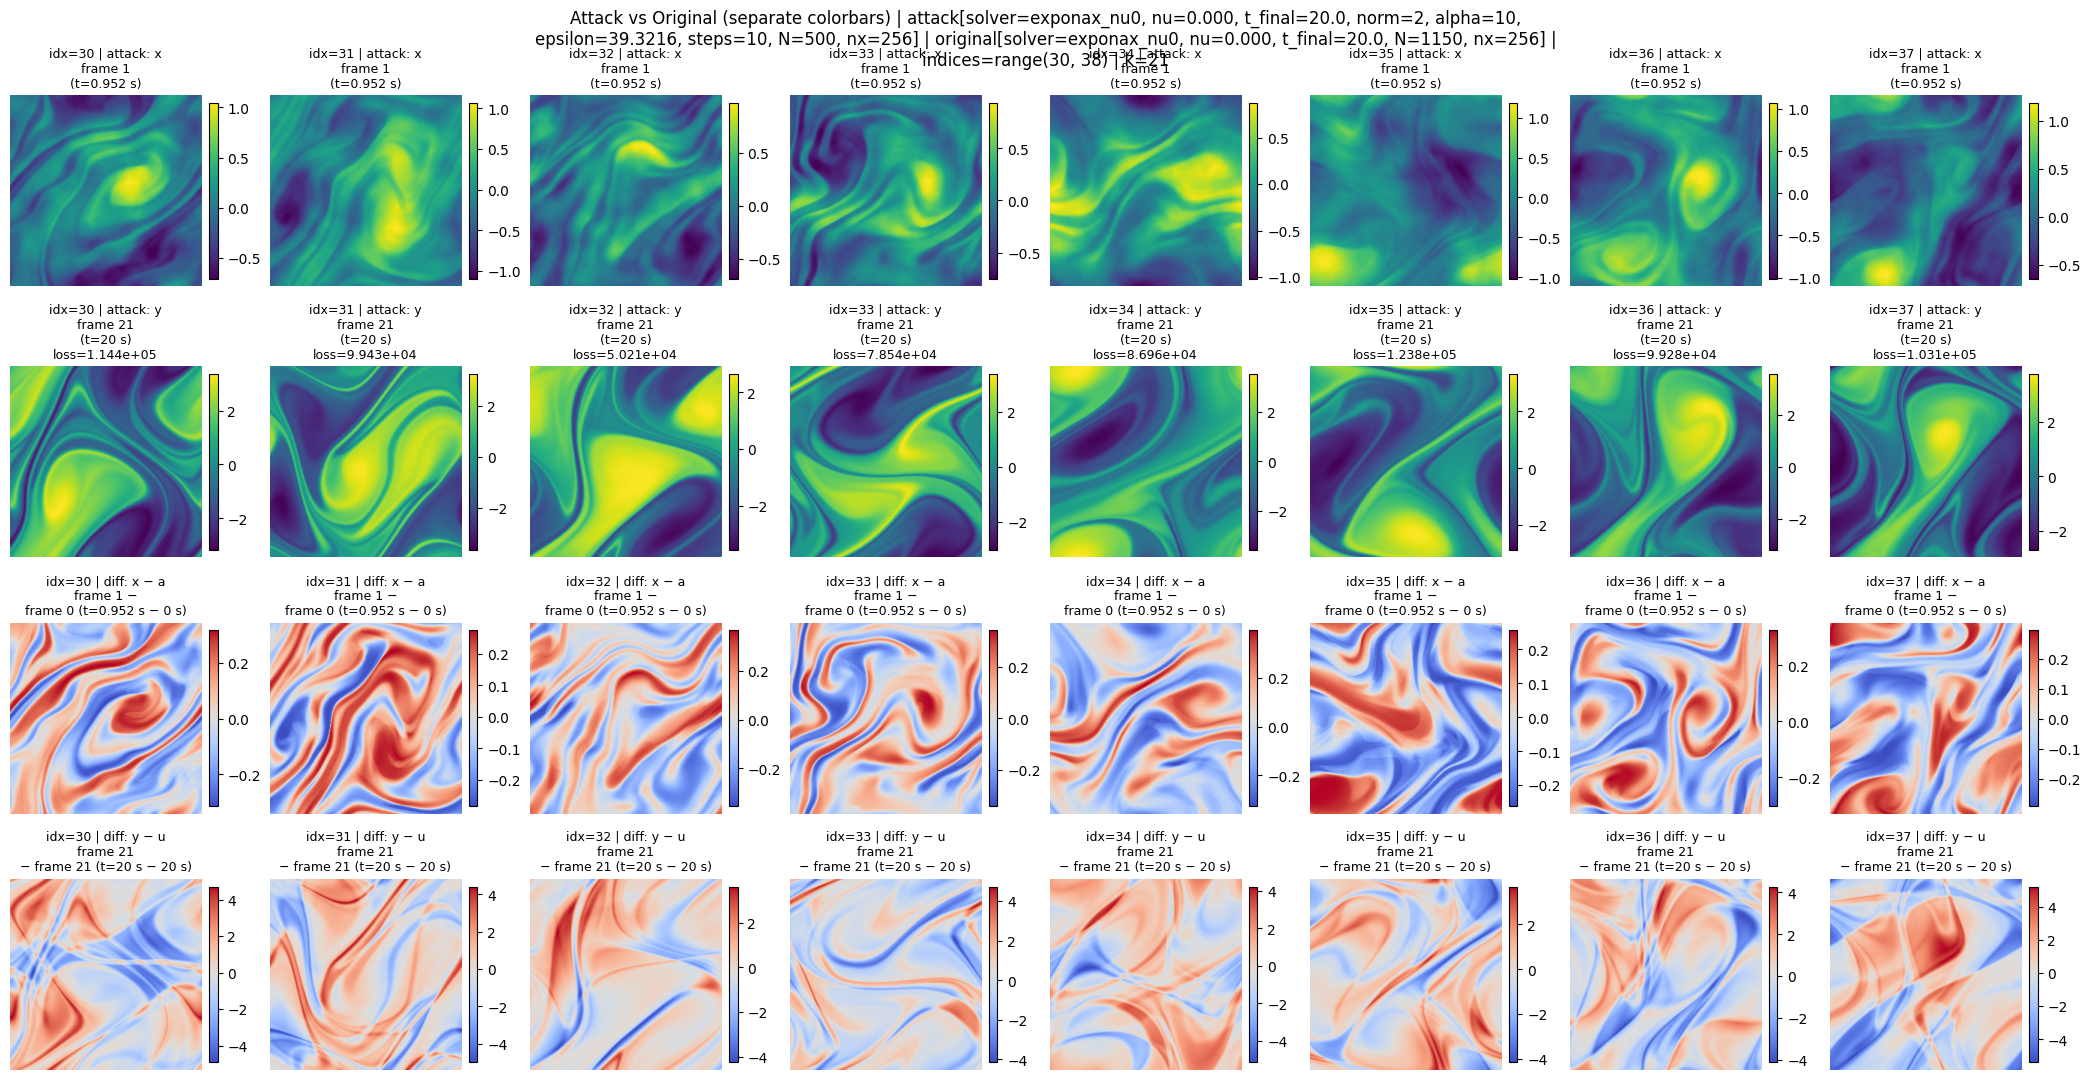

In [7]:
# pt_attack = "dim2d_nx256_N500_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha50_epsilon39.3216_steps10.pt"
pt_attack = "dim2d_nx256_N500_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha10_epsilon39.3216_steps10.pt"

pt_orig   = "../../../exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt"

idxs = range(30,38)   # 8 个 index
fig, axes = plot_xy_compare_attack_original_indices(
    pt_attack, pt_orig, idx_list=idxs, t_idx=-1,
    cmap_attack="viridis", cmap_diff="coolwarm",)
plt.show()

/tmp/ipykernel_1725135/813680429.py:194: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.88)


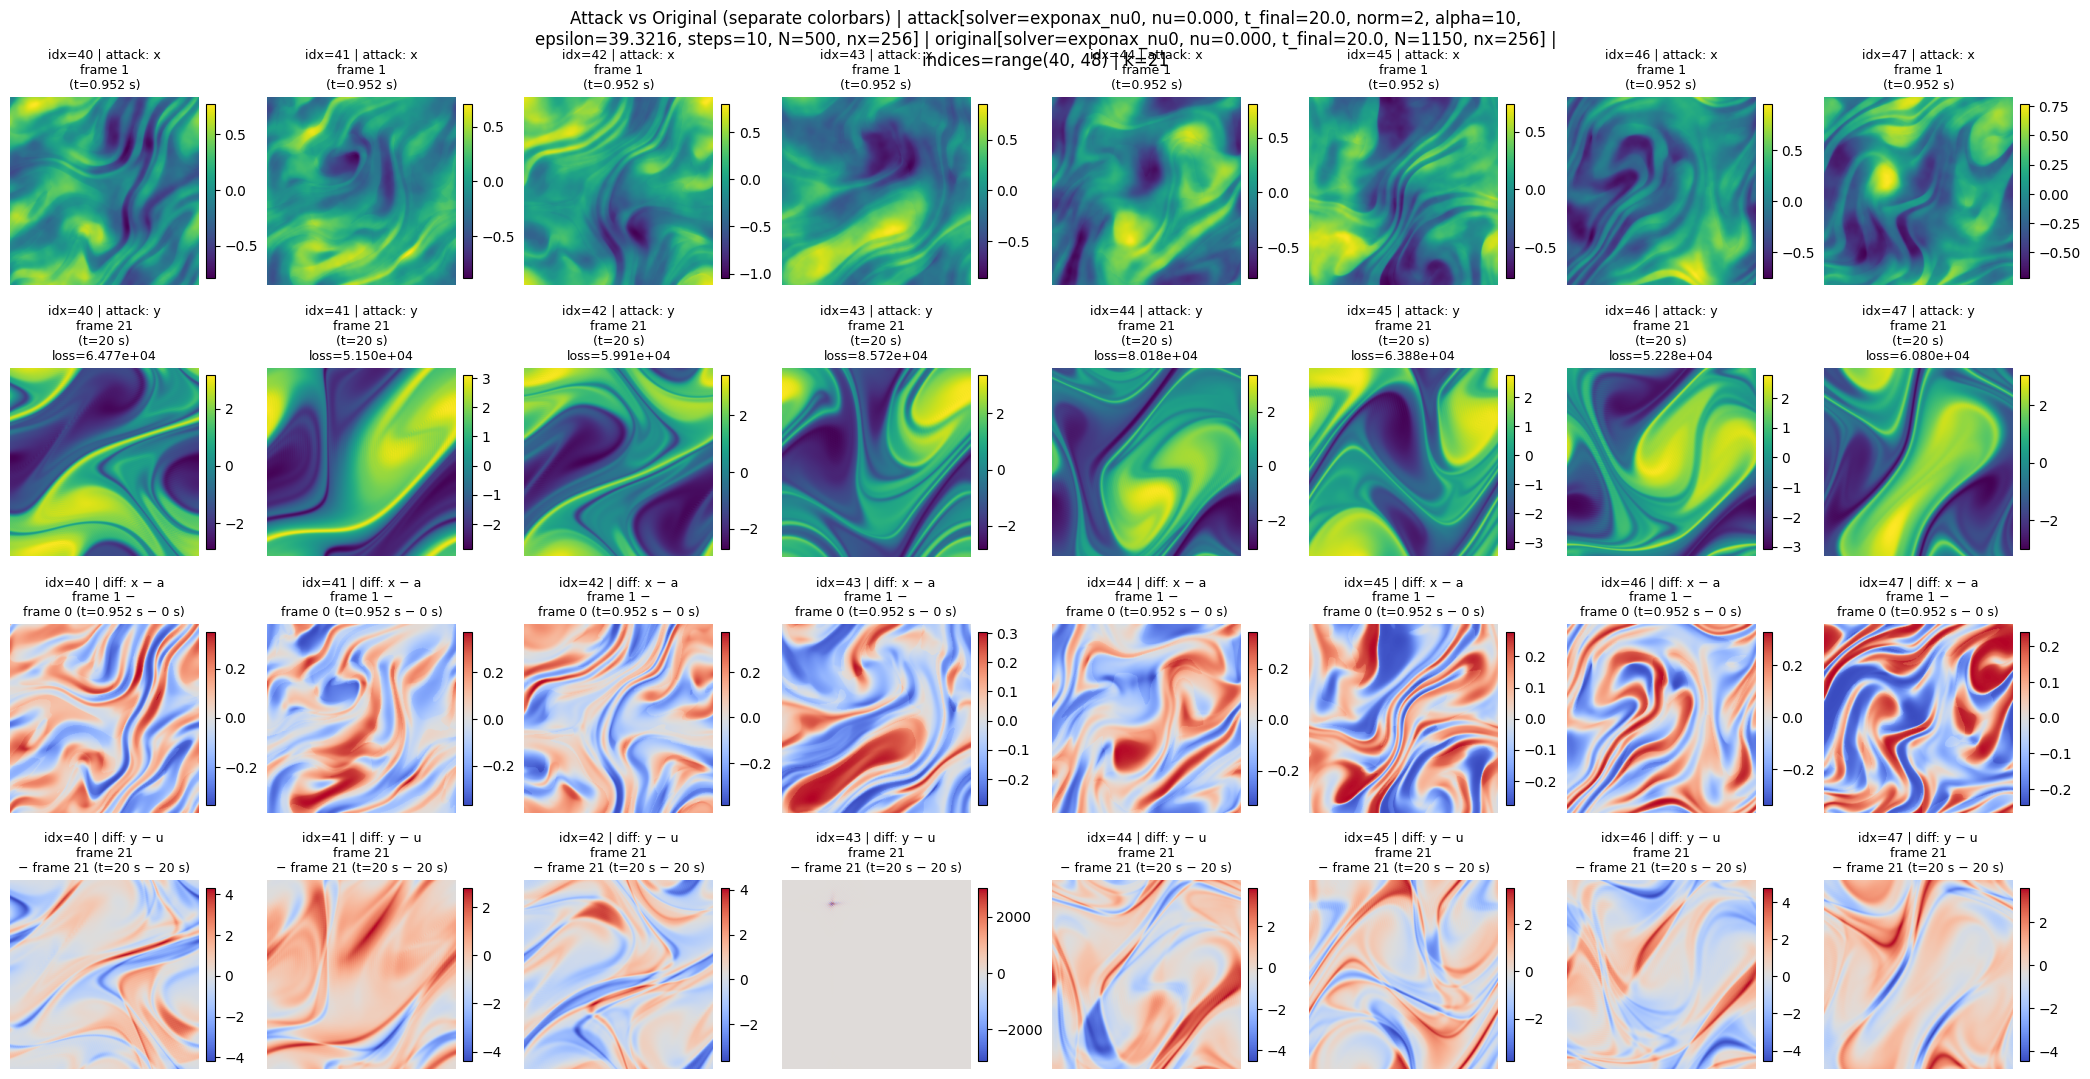

In [9]:
idxs = range(40,48)   # 8 个 index
fig, axes = plot_xy_compare_attack_original_indices(
    pt_attack, pt_orig, idx_list=idxs, t_idx=-1,
    cmap_attack="viridis", cmap_diff="coolwarm",)
plt.show()

In [10]:
import re
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path
import textwrap
import torch
import numpy as np
import matplotlib.pyplot as plt

# ========== Utils ==========

def _load_pt(pt_path: str):
    data = torch.load(pt_path, map_location="cpu", weights_only=False)
    if not all(k in data for k in ["x", "y"]):
        raise KeyError(f"{pt_path} must contain 'x' and 'y'. Keys: {list(data.keys())}")
    return data

def _to_np(t):
    if isinstance(t, torch.Tensor):
        return t.detach().cpu().numpy()
    return np.asarray(t)

def _parse_info_from_name(path_str):
    name = Path(path_str).name
    g = lambda pat: (m.group(1) if (m := re.search(pat, name)) else "")
    return {
        "solver":  g(r"solver=([A-Za-z0-9_]+)"),
        "nu":      g(r"nu([0-9eE\.\-]+)"),
        "t_final": g(r"t([0-9]+(?:\.[0-9]+)?)"),
        "norm":    g(r"norm([^\W_]+)"),
        "alpha":   g(r"alpha([0-9eE\.\-]+)"),
        "epsilon": g(r"epsilon([0-9eE\.\-]+)"),
        "steps":   g(r"steps([0-9]+)"),
        "N":       g(r"N([0-9]+)"),
        "nx":      g(r"nx([0-9]+)"),
    }

def _infer_times(T, t_final):
    # a: t=0; u: t=Δt..TΔt; x: frame1 => t=Δt; y: t=Δt..TΔt
    if not t_final:
        return None, None
    dt = float(t_final) / float(T)
    t_frames = [(k+1)*dt for k in range(T)]
    t_x = dt
    return t_x, t_frames

def _sec_str(t):
    return f"{t:.3g} s" if t is not None else ""

def _wrap(text, width=38):
    return textwrap.fill(text, width=width)

def _desc_from_info(info):
    keys = ["solver", "nu", "t_final", "norm", "alpha", "epsilon", "steps", "nx", "N"]
    parts = [f"{k}={info[k]}" for k in keys if info.get(k)]
    return ", ".join(parts) if parts else "(meta N/A)"

# ========== 单行 8 图：一个 attack + 一个 train = 一行 = 8 个子图 ==========

def plot_row_attack_vs_train_by_index(
    pt_attack: str,
    pt_train: str,
    idx: int,
    t_idx: int = -1,
    wrap_title_width: int = 80,
    cmap_attack: str = "viridis",
    cmap_diff: str = "coolwarm",
    figsize_per_cell: float = 3.2,
):
    """
    一行 8 图：
      [0] attack: x (frame 1)           ┐ shared 组（两根色条：attack 组 + diff 组）
      [1] attack: y (frame k)           │
      [2] diff: x − a (1 − 0)           │
      [3] diff: y − u (k − k)           ┘
      [4] attack: x (frame 1)           ┐ separate 组（每幅各自色条）
      [5] attack: y (frame k)           │
      [6] diff: x − a (1 − 0)           │
      [7] diff: y − u (k − k)           ┘
    """
    da = _load_pt(pt_attack)
    dt = _load_pt(pt_train)
    x_att, y_att = da["x"], da["y"]
    a_org, u_org = dt["x"], dt["y"]

    if x_att.ndim != 3 or a_org.ndim != 3:
        raise ValueError(f"x/a must be (N,H,W). Got {x_att.shape} and {a_org.shape}")
    if y_att.ndim != 4 or u_org.ndim != 4:
        raise ValueError(f"y/u must be (N,H,W,T). Got {y_att.shape} and {u_org.shape}")

    # 帧数对齐
    T = min(y_att.shape[3], u_org.shape[3])
    k = (t_idx % T)

    # 取 numpy
    x_np = _to_np(x_att[idx])            # attack: x (frame 1)
    y_np = _to_np(y_att[idx, :, :, k])   # attack: y (frame k)
    a_np = _to_np(a_org[idx])            # train:  a (frame 0)
    u_np = _to_np(u_org[idx, :, :, k])   # train:  u (frame k)

    # 差分
    xd = x_np - a_np                      # frame1 - frame0
    yd = y_np - u_np                      # frame k - frame k

    # 时间标签
    info_att = _parse_info_from_name(pt_attack)
    info_org = _parse_info_from_name(pt_train)
    t_final = info_att.get("t_final") or info_org.get("t_final")
    t_x, t_frames = _infer_times(T, t_final)
    t_k = t_frames[k] if t_frames is not None else None

    # shared 组色域
    vmin_att = float(min(x_np.min(), y_np.min()))
    vmax_att = float(max(x_np.max(), y_np.max()))
    vmin_diff = float(min(xd.min(), yd.min()))
    vmax_diff = float(max(xd.max(), yd.max()))

    # 画图
    ncols = 8
    fig, axes = plt.subplots(
        1, ncols,
        figsize=(figsize_per_cell*ncols, figsize_per_cell*1.0),
        constrained_layout=True
    )

    # ---- 左 4：shared 组（两根色条）
    ims_left = []
    im0 = axes[0].imshow(x_np, cmap=cmap_attack, vmin=vmin_att, vmax=vmax_att); ims_left.append(im0)
    axes[0].set_title(_wrap(f"attack: x\n(frame 1, t={_sec_str(t_x)})", 20)); axes[0].axis("off")

    im1 = axes[1].imshow(y_np, cmap=cmap_attack, vmin=vmin_att, vmax=vmax_att); ims_left.append(im1)
    axes[1].set_title(_wrap(f"attack: y\n(frame {k+1}, t={_sec_str(t_k)})", 20)); axes[1].axis("off")

    im2 = axes[2].imshow(xd, cmap=cmap_diff,   vmin=vmin_diff, vmax=vmax_diff); ims_left.append(im2)
    axes[2].set_title(_wrap(f"diff: x − a\n(1 − 0, t={_sec_str(t_x)} − 0 s)", 20)); axes[2].axis("off")

    im3 = axes[3].imshow(yd, cmap=cmap_diff,   vmin=vmin_diff, vmax=vmax_diff); ims_left.append(im3)
    axes[3].set_title(_wrap(f"diff: y − u\n({k+1} − {k+1}, t={_sec_str(t_k)} − {_sec_str(t_k)})", 20)); axes[3].axis("off")

    # 两根共享色条
    fig.colorbar(im1, ax=axes[0:2].tolist(), fraction=0.04, pad=0.02)
    fig.colorbar(im3, ax=axes[2:4].tolist(), fraction=0.04, pad=0.02)

    # ---- 右 4：separate 组（每幅各自色条）
    im4 = axes[4].imshow(x_np, cmap=cmap_attack); axes[4].axis("off")
    axes[4].set_title(_wrap(f"attack: x\n(frame 1, t={_sec_str(t_x)})", 20))
    fig.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.04)

    im5 = axes[5].imshow(y_np, cmap=cmap_attack); axes[5].axis("off")
    axes[5].set_title(_wrap(f"attack: y\n(frame {k+1}, t={_sec_str(t_k)})", 20))
    fig.colorbar(im5, ax=axes[5], fraction=0.046, pad=0.04)

    im6 = axes[6].imshow(xd, cmap=cmap_diff); axes[6].axis("off")
    axes[6].set_title(_wrap(f"diff: x − a\n(1 − 0, t={_sec_str(t_x)} − 0 s)", 20))
    fig.colorbar(im6, ax=axes[6], fraction=0.046, pad=0.04)

    im7 = axes[7].imshow(yd, cmap=cmap_diff); axes[7].axis("off")
    axes[7].set_title(_wrap(f"diff: y − u\n({k+1} − {k+1}, t={_sec_str(t_k)} − {_sec_str(t_k)})", 20))
    fig.colorbar(im7, ax=axes[7], fraction=0.046, pad=0.04)

    # 行级标签：写在第 0 列左侧（即使 axis off 也能显示标签）
    desc_att = _desc_from_info(info_att)
    axes[0].set_ylabel(_wrap(f"attack[{desc_att}]\nindex={idx}, k={k+1}", wrap_title_width),
                       rotation=0, ha="right", va="center", fontsize=10)
    axes[0].yaxis.set_label_coords(-0.12, 0.5)

    # 顶部留白，避免标题重叠
    fig.subplots_adjust(top=0.86)
    return fig, axes

# ========== 多行 8 图：多个 attack 与同一个 train ==========

def plot_rows_attack_vs_train_by_index(
    pt_attack_list,
    pt_train: str,
    idx: int,
    t_idx: int = -1,
    wrap_title_width: int = 80,
    cmap_attack: str = "viridis",
    cmap_diff: str = "coolwarm",
    figsize_per_cell: float = 3.2,
):
    """
    参数：
      pt_attack_list: list[str] 多个 attack 数据集路径
      pt_train:       单个 train/original 路径
      idx, t_idx:     采样编号与帧号
    输出：
      N 行 × 8 列；每行一套（shared 组 4 图 + separate 组 4 图）
    """
    assert isinstance(pt_attack_list, (list, tuple)) and len(pt_attack_list) > 0, "pt_attack_list must be a non-empty list"

    nrows = len(pt_attack_list)
    ncols = 8
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_cell*ncols, figsize_per_cell*nrows),
        constrained_layout=True
    )
    if nrows == 1:
        axes = np.expand_dims(axes, 0)  # 统一成 2D

    # 逐行画
    for r, pta in enumerate(pt_attack_list):
        # 直接调用单行函数绘制到“临时图”，然后把绘制逻辑改为“就地在 axes[r] 绘制”
        # 这里我们直接复用上面的逻辑，仅把 'axes' 换成这一行的 axes[r]
        da = _load_pt(pta)
        dt = _load_pt(pt_train)
        x_att, y_att = da["x"], da["y"]
        a_org, u_org = dt["x"], dt["y"]

        if y_att.ndim != 4 or u_org.ndim != 4:
            raise ValueError(f"y/u must be (N,H,W,T). Got {y_att.shape} and {u_org.shape}")
        if x_att.ndim != 3 or a_org.ndim != 3:
            raise ValueError(f"x/a must be (N,H,W). Got {x_att.shape} and {a_org.shape}")

        T = min(y_att.shape[3], u_org.shape[3])
        k = (t_idx % T)
        x_np = _to_np(x_att[idx])
        y_np = _to_np(y_att[idx, :, :, k])
        a_np = _to_np(a_org[idx])
        u_np = _to_np(u_org[idx, :, :, k])
        xd = x_np - a_np
        yd = y_np - u_np

        info_att = _parse_info_from_name(pta)
        info_org = _parse_info_from_name(pt_train)
        t_final = info_att.get("t_final") or info_org.get("t_final")
        t_x, t_frames = _infer_times(T, t_final)
        t_k = t_frames[k] if t_frames is not None else None

        vmin_att = float(min(x_np.min(), y_np.min()))
        vmax_att = float(max(x_np.max(), y_np.max()))
        vmin_diff = float(min(xd.min(), yd.min()))
        vmax_diff = float(max(xd.max(), yd.max()))

        row_axes = axes[r]

        # shared left 4
        im0 = row_axes[0].imshow(x_np, cmap=cmap_attack, vmin=vmin_att, vmax=vmax_att); row_axes[0].axis("off")
        row_axes[0].set_title(_wrap(f"attack: x\n(frame 1, t={_sec_str(t_x)})", 20))
        im1 = row_axes[1].imshow(y_np, cmap=cmap_attack, vmin=vmin_att, vmax=vmax_att); row_axes[1].axis("off")
        row_axes[1].set_title(_wrap(f"attack: y\n(frame {k+1}, t={_sec_str(t_k)})", 20))
        im2 = row_axes[2].imshow(xd,   cmap=cmap_diff,   vmin=vmin_diff, vmax=vmax_diff); row_axes[2].axis("off")
        row_axes[2].set_title(_wrap(f"diff: x − a\n(1 − 0, t={_sec_str(t_x)} − 0 s)", 20))
        im3 = row_axes[3].imshow(yd,   cmap=cmap_diff,   vmin=vmin_diff, vmax=vmax_diff); row_axes[3].axis("off")
        row_axes[3].set_title(_wrap(f"diff: y − u\n({k+1} − {k+1}, t={_sec_str(t_k)} − {_sec_str(t_k)})", 20))

        # shared colorbars (两根)
        fig.colorbar(im1, ax=row_axes[0:2].tolist(), fraction=0.04, pad=0.02)
        fig.colorbar(im3, ax=row_axes[2:4].tolist(), fraction=0.04, pad=0.02)

        # separate right 4
        im4 = row_axes[4].imshow(x_np, cmap=cmap_attack); row_axes[4].axis("off")
        row_axes[4].set_title(_wrap(f"attack: x\n(frame 1, t={_sec_str(t_x)})", 20))
        fig.colorbar(im4, ax=row_axes[4], fraction=0.046, pad=0.04)

        im5 = row_axes[5].imshow(y_np, cmap=cmap_attack); row_axes[5].axis("off")
        row_axes[5].set_title(_wrap(f"attack: y\n(frame {k+1}, t={_sec_str(t_k)})", 20))
        fig.colorbar(im5, ax=row_axes[5], fraction=0.046, pad=0.04)

        im6 = row_axes[6].imshow(xd,   cmap=cmap_diff);   row_axes[6].axis("off")
        row_axes[6].set_title(_wrap(f"diff: x − a\n(1 − 0, t={_sec_str(t_x)} − 0 s)", 20))
        fig.colorbar(im6, ax=row_axes[6], fraction=0.046, pad=0.04)

        im7 = row_axes[7].imshow(yd,   cmap=cmap_diff);   row_axes[7].axis("off")
        row_axes[7].set_title(_wrap(f"diff: y − u\n({k+1} − {k+1}, t={_sec_str(t_k)} − {_sec_str(t_k)})", 20))
        fig.colorbar(im7, ax=row_axes[7], fraction=0.046, pad=0.04)

        # 行标签（写在第 0 列左侧）
        desc_att = _desc_from_info(info_att)
        row_axes[0].set_ylabel(_wrap(f"attack[{desc_att}]\nindex={idx}, k={k+1}", wrap_title_width),
                               rotation=0, ha="right", va="center", fontsize=10)
        row_axes[0].yaxis.set_label_coords(-0.12, 0.5)

    # 整体标题（可选）
    desc_org = _desc_from_info(_parse_info_from_name(pt_train))
    fig.suptitle(_wrap(f"Attack vs Train (shared+separate colorbars per row)  |  train[{desc_org}]", 120),
                 y=0.995, fontsize=12)
    fig.subplots_adjust(top=0.93)
    return fig, axes
# ---------- utils ----------
def _load_pt(pt_path):
    data = torch.load(pt_path, map_location="cpu", weights_only=False)
    if not all(k in data for k in ["x", "y"]):
        raise KeyError(f"{pt_path} must contain 'x' and 'y'. Keys: {list(data.keys())}")
    return data

def _to_np(t):
    if isinstance(t, torch.Tensor):
        return t.detach().cpu().numpy()
    return np.asarray(t)

def _parse_info_from_name(path_str):
    """尽量从文件名里解析出关键信息；取不到的留空。"""
    name = Path(path_str).name
    info = {}
    m = re.search(r"solver=([A-Za-z0-9_]+)", name);         info["solver"]  = m.group(1) if m else ""
    m = re.search(r"nu([0-9eE\.\-]+)", name);               info["nu"]      = m.group(1) if m else ""
    m = re.search(r"t([0-9]+(?:\.[0-9]+)?)", name);         info["t_final"] = m.group(1) if m else ""
    m = re.search(r"norm([^\W_]+)", name);                  info["norm"]    = m.group(1) if m else ""
    m = re.search(r"alpha([0-9eE\.\-]+)", name);            info["alpha"]   = m.group(1) if m else ""
    m = re.search(r"epsilon([0-9eE\.\-]+)", name);          info["epsilon"] = m.group(1) if m else ""
    m = re.search(r"steps([0-9]+)", name);                  info["steps"]   = m.group(1) if m else ""
    m = re.search(r"N([0-9]+)", name);                      info["N"]       = m.group(1) if m else ""
    m = re.search(r"nx([0-9]+)", name);                     info["nx"]      = m.group(1) if m else ""
    return info

def _infer_times(T, t_final):
    """给 y/u 的帧生成时间（秒）数组。约定：y/u 的帧是 1..T，对应 t=Δt,2Δt,...,TΔt；a 为 t=0, x 为 t=Δt。"""
    if not t_final:
        return None, None
    dt = float(t_final) / float(T)
    t_frames = [(k+1)*dt for k in range(T)]  # y/u: k=0..T-1 -> t=(k+1)*dt
    t_x = dt  # frame1
    return t_x, t_frames

def _sec_str(t):
    return f"{t:.3g} s"

# ---------- 1) 单图：先在样本维度[:N]平均，再画 x / y(k) / (x-a) / (y(k)-u(k)) ----------
def plot_xy_compare_attack_original_avg(
    pt_attack: str,
    pt_original: str,
    N: int,
    t_idx: int = -1,               # 展示的 y/u 帧（-1 表示最后一帧）
    cmap_attack: str = "viridis",
    cmap_diff: str = "coolwarm",
    cbar_mode: str = "shared",     # "shared": 两组各 1 根；"separate": 每幅子图单独
):
    """
    对 attack/original 的前 N 条样本在第 0 维求均值后作图。
    左：attack（x = frame 1, y(k) = frame k）
    右：difference（x - a = frame1 - frame0, y(k) - u(k) = frame k - frame k）
    标题只用 x/a/y(k)/u(k) 命名；第二行写清楚帧号和时间（秒）。
    """
    da = _load_pt(pt_attack)
    do = _load_pt(pt_original)
    x_att, y_att = da["x"], da["y"]
    x_org, y_org = do["x"], do["y"]  # original: a, u

    if x_att.ndim != 3 or x_org.ndim != 3:
        raise ValueError(f"x must be (N,H,W). Got {tuple(x_att.shape)} and {tuple(x_org.shape)}")
    if y_att.ndim != 4 or y_org.ndim != 4:
        raise ValueError(f"y must be (N,H,W,T). Got {tuple(y_att.shape)} and {tuple(y_org.shape)}")

    # 截断 N
    N_use = min(N, x_att.shape[0], x_org.shape[0], y_att.shape[0], y_org.shape[0])

    # 帧对齐
    T_att, T_org = y_att.shape[3], y_org.shape[3]
    T = min(T_att, T_org)
    if T_att != T_org:
        print(f"[info] frame mismatch: attack T={T_att}, original T={T_org}. Use T={T} (drop extras).")

    # 平均（第 0 维）
    x_avg = x_att[:N_use].mean(dim=0)          # (H, W)      -> attack: x(frame1)
    a_avg = x_org[:N_use].mean(dim=0)          # (H, W)      -> original: a(frame0)
    y_avg = y_att[:N_use, :, :, :T].mean(dim=0)  # (H, W, T) -> attack: y
    u_avg = y_org[:N_use, :, :, :T].mean(dim=0)  # (H, W, T) -> original: u

    # 选择帧 k
    k = t_idx % T
    y_k = _to_np(y_avg[..., k])
    u_k = _to_np(u_avg[..., k])

    # numpy 转换
    x_np = _to_np(x_avg)
    a_np = _to_np(a_avg)

    # 差分
    xd = x_np - a_np
    yd = y_k - u_k

    # 时间（秒）
    info_att = _parse_info_from_name(pt_attack)
    info_org = _parse_info_from_name(pt_original)
    t_final_str = info_att.get("t_final") or info_org.get("t_final") or ""
    t_x, t_frames = _infer_times(T, t_final_str)
    t_k = t_frames[k] if t_frames is not None else None

    # vmin/vmax
    if cbar_mode == "shared":
        vmin_att = min(float(x_np.min()), float(y_k.min()))
        vmax_att = max(float(x_np.max()), float(y_k.max()))
        vmin_diff = min(float(xd.min()), float(yd.min()))
        vmax_diff = max(float(xd.max()), float(yd.max()))
    else:
        vmin_att = vmax_att = vmin_diff = vmax_diff = None

    # 绘图：1×4（x, y(k), x-a, y(k)-u(k)）
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
    ims = []

    # x
    im = axes[0].imshow(x_np, cmap=cmap_attack, vmin=vmin_att, vmax=vmax_att)
    line2 = "(frame 1" + (f", t={_sec_str(t_x)}" if t_x is not None else "") + ")"
    axes[0].set_title("attack: x\n" + line2)
    axes[0].axis("off"); ims.append(im)

    # y(k)
    im = axes[1].imshow(y_k, cmap=cmap_attack, vmin=vmin_att, vmax=vmax_att)
    line2 = f"(frame {k+1}" + (f", t={_sec_str(t_k)}" if t_k is not None else "") + ")"
    axes[1].set_title("attack: y\n" + line2)
    axes[1].axis("off"); ims.append(im)

    # x-a
    im = axes[2].imshow(xd, cmap=cmap_diff, vmin=vmin_diff, vmax=vmax_diff)
    t_part = (f", t={_sec_str(t_x)} − {_sec_str(0.0)}" if t_x is not None else "")
    axes[2].set_title("diff: x − a\n(frame 1 − frame 0" + t_part + ")")
    axes[2].axis("off"); ims.append(im)

    # y(k)-u(k)
    im = axes[3].imshow(yd, cmap=cmap_diff, vmin=vmin_diff, vmax=vmax_diff)
    t_part = (f", t={_sec_str(t_k)} − {_sec_str(t_k)}" if t_k is not None else "")
    axes[3].set_title("diff: y − u\n(frame {0} − frame {0}{1})".format(k+1, t_part))
    axes[3].axis("off"); ims.append(im)

    # colorbar
    if cbar_mode == "shared":
        fig.colorbar(ims[1], ax=axes[:2].tolist(), fraction=0.04, pad=0.02)   # attack 组
        fig.colorbar(ims[3], ax=axes[2:].tolist(), fraction=0.04, pad=0.02)   # diff 组
    else:
        for ax, im in zip(axes, ims):
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # 大标题：加关键信息 + N（均值样本数），抬高避免重叠
    desc_att = ", ".join([f"{k}={v}" for k, v in info_att.items() if v])
    desc_org = ", ".join([f"{k}={v}" for k, v in info_org.items() if v])
    fig.suptitle(
        f"Mean over first N={N_use} records | Attack vs Difference | "
        f"attack[{desc_att}] | original[{desc_org}]",
        y=1.05, fontsize=13
    )
    plt.show()
    return fig, axes

# ---------- 2) 多帧翻倍：先平均，再画左 y(k) / 右 y(k)-u(k)（5×10） ----------
def plot_frames_y_and_diff_side_by_side_avg(
    pt_attack: str,
    pt_original: str,
    N: int,
    grid=(5, 5),                 # 左半区网格；右半区自动水平扩一倍 -> (rows, 2*cols)
    cmap_attack: str = "viridis",
    cmap_diff: str = "coolwarm",
    cbar_mode: str = "shared",   # "shared": 每组 1 根；"separate": 每帧各自 2 根
):
    """
    对 attack/original 的前 N 条样本在第 0 维求均值后作图。
    左：attack 的 y(k)（标注 “attack: y(k)”）
    右：difference = y(k) - u(k)（标注 “diff: y(k) − u(k)”）

    - 总布局：rows × (2*cols)，默认 5×10。
    - 若 T < rows*cols：多余子图留空；若 T > rows*cols：只画前 rows*cols 帧。
    - 帧数按两数据集公共 T 对齐（多出的帧丢弃）。
    - colorbar:
        * shared   -> 左组 1 根，右组 1 根（组内统一 vmin/vmax）
        * separate -> 每个帧各 2 根（该帧左/右各自 vmin/vmax）
    """
    da = _load_pt(pt_attack)
    do = _load_pt(pt_original)
    y_att, y_org = da["y"], do["y"]

    if y_att.ndim != 4 or y_org.ndim != 4:
        raise ValueError(f"y must be (N,H,W,T). Got {tuple(y_att.shape)} and {tuple(y_org.shape)}")

    # 截断 N
    N_use = min(N, y_att.shape[0], y_org.shape[0])

    # 帧对齐
    T_att, T_org = y_att.shape[3], y_org.shape[3]
    T = min(T_att, T_org)
    if T_att != T_org:
        print(f"[info] frame mismatch: attack T={T_att}, original T={T_org}. Use T={T} (drop extras).")

    rows, cols = grid
    K = rows * cols
    num_to_plot = min(T, K)

    # 平均并转 numpy
    y_p = _to_np(y_att[:N_use, :, :, :T].mean(axis=0))   # (H, W, T) -> attack: y
    u_o = _to_np(y_org[:N_use, :, :, :T].mean(axis=0))   # (H, W, T) -> original: u
    y_d = y_p - u_o                                      # difference

    # 时间（仅用于标题）
    info_att = _parse_info_from_name(pt_attack)
    info_org = _parse_info_from_name(pt_original)
    t_final_str = info_att.get("t_final") or info_org.get("t_final") or ""
    _, t_frames = _infer_times(T, t_final_str)

    # vmin/vmax（shared: 组内统一；separate: 每帧各自）
    if cbar_mode == "shared":
        vmin_left  = float(np.min(y_p[..., :num_to_plot]))
        vmax_left  = float(np.max(y_p[..., :num_to_plot]))
        vmin_right = float(np.min(y_d[..., :num_to_plot]))
        vmax_right = float(np.max(y_d[..., :num_to_plot]))
    else:
        vmin_left = vmax_left = vmin_right = vmax_right = None

    # 布局：rows × (2*cols)
    fig, axes = plt.subplots(rows, 2*cols, figsize=(2*cols*2.2, rows*2.2), constrained_layout=True)
    axes = np.asarray(axes)

    ims_left, ims_right = [], []

    # 左：attack y 全帧
    for k in range(K):
        r, c = divmod(k, cols)
        ax = axes[r, c]
        if k < num_to_plot:
            if cbar_mode == "shared":
                im = ax.imshow(y_p[..., k], cmap=cmap_attack, vmin=vmin_left, vmax=vmax_left)
            else:
                im = ax.imshow(y_p[..., k], cmap=cmap_attack)
            t_k = (t_frames[k] if (t_frames is not None and k < len(t_frames)) else None)
            ax.set_title(
                "attack: y(k={})\n{}".format(k+1, f"t={_sec_str(t_k)}" if t_k is not None else ""),
                fontsize=9
            )
            ims_left.append(im)
        ax.axis("off")

    # 右：difference (y - u) 全帧
    for k in range(K):
        r, c = divmod(k, cols)
        ax = axes[r, cols + c]
        if k < num_to_plot:
            if cbar_mode == "shared":
                im = ax.imshow(y_d[..., k], cmap=cmap_diff, vmin=vmin_right, vmax=vmax_right)
            else:
                im = ax.imshow(y_d[..., k], cmap=cmap_diff)
            t_k = (t_frames[k] if (t_frames is not None and k < len(t_frames)) else None)
            ax.set_title(
                "diff: y(k) − u(k)\n{}".format(
                    f"t={_sec_str(t_k)} − { _sec_str(t_k) }" if t_k is not None else ""
                ),
                fontsize=9
            )
            ims_right.append(im)
        ax.axis("off")

    # colorbar
    if cbar_mode == "shared":
        if ims_left:
            fig.colorbar(ims_left[-1],  ax=axes[:, :cols].ravel().tolist(), fraction=0.02, pad=0.01)
        if ims_right:
            fig.colorbar(ims_right[-1], ax=axes[:, cols:].ravel().tolist(), fraction=0.02, pad=0.01)
    else:  # 每帧各自两根（左/右）
        for k in range(num_to_plot):
            r, c = divmod(k, cols)
            axL = axes[r, c]
            axR = axes[r, cols + c]
            if axL.images:
                fig.colorbar(axL.images[0], ax=axL, fraction=0.036, pad=0.01)
            if axR.images:
                fig.colorbar(axR.images[0], ax=axR, fraction=0.036, pad=0.01)

    # 大标题：带关键信息与 N（均值样本数），抬高避免重叠
    desc_att = ", ".join([f"{k}={v}" for k, v in info_att.items() if v])
    desc_org = ", ".join([f"{k}={v}" for k, v in info_org.items() if v])
    fig.suptitle(
        f"Mean over first N={N_use} records | Attack y(k) vs Difference y(k)-u(k) | "
        f"attack[{desc_att}] | original[{desc_org}]",
        y=1.05, fontsize=13
    )
    plt.show()
    return fig, axes

# ===== 单行 8 图：一个 attack + 一个 train，先对前 N 条样本做均值 =====
def plot_row_attack_vs_train_meanN(
    pt_attack: str,
    pt_train: str,
    N: int,
    t_idx: int = -1,
    wrap_title_width: int = 80,
    cmap_attack: str = "viridis",
    cmap_diff: str = "coolwarm",
    figsize_per_cell: float = 3.2,
):
    da = _load_pt(pt_attack)
    dt = _load_pt(pt_train)
    x_att, y_att = da["x"], da["y"]   # x=frame1, y=frames 1..T
    a_org, u_org = dt["x"], dt["y"]   # a=frame0, u=frames 1..T

    if x_att.ndim != 3 or a_org.ndim != 3:
        raise ValueError(f"x/a must be (N,H,W). Got {x_att.shape} and {a_org.shape}")
    if y_att.ndim != 4 or u_org.ndim != 4:
        raise ValueError(f"y/u must be (N,H,W,T). Got {y_att.shape} and {u_org.shape}")

    T = min(y_att.shape[3], u_org.shape[3])
    N_use = min(N, x_att.shape[0], a_org.shape[0], y_att.shape[0], u_org.shape[0])
    k = (t_idx % T)

    # 均值（样本维度）
    x_avg = x_att[:N_use].mean(dim=0)            # (H,W)
    a_avg = a_org[:N_use].mean(dim=0)            # (H,W)
    y_avg = y_att[:N_use, :, :, :T].mean(dim=0)  # (H,W,T)
    u_avg = u_org[:N_use, :, :, :T].mean(dim=0)  # (H,W,T)

    # 取第 k 帧
    x_np = _to_np(x_avg)
    a_np = _to_np(a_avg)
    y_np = _to_np(y_avg[..., k])
    u_np = _to_np(u_avg[..., k])

    # 差分
    xd = x_np - a_np
    yd = y_np - u_np

    # 时间标签
    info_att = _parse_info_from_name(pt_attack)
    info_org = _parse_info_from_name(pt_train)
    t_final = info_att.get("t_final") or info_org.get("t_final")
    t_x, t_frames = _infer_times(T, t_final)
    t_k = t_frames[k] if t_frames is not None else None

    # shared 组色域
    vmin_att = float(min(x_np.min(), y_np.min()))
    vmax_att = float(max(x_np.max(), y_np.max()))
    vmin_diff = float(min(xd.min(), yd.min()))
    vmax_diff = float(max(xd.max(), yd.max()))

    # 8 个子图（左 4 shared，右 4 separate）
    ncols = 8
    fig, axes = plt.subplots(
        1, ncols,
        figsize=(figsize_per_cell*ncols, figsize_per_cell*1.0),
        constrained_layout=True
    )

    # -- 左 4：shared（两根色条）
    im0 = axes[0].imshow(x_np, cmap=cmap_attack, vmin=vmin_att, vmax=vmax_att); axes[0].axis("off")
    axes[0].set_title(_wrap(f"attack: x\n(frame 1, t={_sec_str(t_x)})", 20))
    im1 = axes[1].imshow(y_np, cmap=cmap_attack, vmin=vmin_att, vmax=vmax_att); axes[1].axis("off")
    axes[1].set_title(_wrap(f"attack: y\n(frame {k+1}, t={_sec_str(t_k)})", 20))
    im2 = axes[2].imshow(xd,   cmap=cmap_diff,   vmin=vmin_diff, vmax=vmax_diff); axes[2].axis("off")
    axes[2].set_title(_wrap(f"diff: x − a\n(1 − 0, t={_sec_str(t_x)} − 0 s)", 20))
    im3 = axes[3].imshow(yd,   cmap=cmap_diff,   vmin=vmin_diff, vmax=vmax_diff); axes[3].axis("off")
    axes[3].set_title(_wrap(f"diff: y − u\n({k+1} − {k+1}, t={_sec_str(t_k)} − {_sec_str(t_k)})", 20))

    # 两根共享色条
    fig.colorbar(im1, ax=axes[0:2].tolist(), fraction=0.04, pad=0.02)
    fig.colorbar(im3, ax=axes[2:4].tolist(), fraction=0.04, pad=0.02)

    # -- 右 4：separate（每幅各自色条）
    im4 = axes[4].imshow(x_np, cmap=cmap_attack); axes[4].axis("off")
    axes[4].set_title(_wrap(f"attack: x\n(frame 1, t={_sec_str(t_x)})", 20))
    fig.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.04)

    im5 = axes[5].imshow(y_np, cmap=cmap_attack); axes[5].axis("off")
    axes[5].set_title(_wrap(f"attack: y\n(frame {k+1}, t={_sec_str(t_k)})", 20))
    fig.colorbar(im5, ax=axes[5], fraction=0.046, pad=0.04)

    im6 = axes[6].imshow(xd,   cmap=cmap_diff);   axes[6].axis("off")
    axes[6].set_title(_wrap(f"diff: x − a\n(1 − 0, t={_sec_str(t_x)} − 0 s)", 20))
    fig.colorbar(im6, ax=axes[6], fraction=0.046, pad=0.04)

    im7 = axes[7].imshow(yd,   cmap=cmap_diff);   axes[7].axis("off")
    axes[7].set_title(_wrap(f"diff: y − u\n({k+1} − {k+1}, t={_sec_str(t_k)})", 20))
    fig.colorbar(im7, ax=axes[7], fraction=0.046, pad=0.04)

    # 行标签（写在第 0 列左侧）
    desc_att = _desc_from_info(info_att)
    axes[0].set_ylabel(_wrap(f"attack[{desc_att}]\nmean of first N={N_use}, k={k+1}", wrap_title_width),
                       rotation=0, ha="right", va="center", fontsize=10)
    axes[0].yaxis.set_label_coords(-0.12, 0.5)

    fig.subplots_adjust(top=0.86)
    return fig, axes


# ===== 多行 8 图：多个 attack + 一个 train，先对前 N 条样本做均值，每个 attack 占一行 =====
def plot_rows_attack_vs_train_meanN(
    pt_attack_list,
    pt_train: str,
    N: int,
    t_idx: int = -1,
    wrap_title_width: int = 80,
    cmap_attack: str = "viridis",
    cmap_diff: str = "coolwarm",
    figsize_per_cell: float = 3.2,
):
    assert isinstance(pt_attack_list, (list, tuple)) and len(pt_attack_list) > 0, \
        "pt_attack_list must be a non-empty list"

    nrows = len(pt_attack_list)
    ncols = 8
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_cell*ncols, figsize_per_cell*nrows),
        constrained_layout=True
    )
    if nrows == 1:
        axes = np.expand_dims(axes, 0)

    for r, pta in enumerate(pt_attack_list):
        da = _load_pt(pta); dt = _load_pt(pt_train)
        x_att, y_att = da["x"], da["y"]
        a_org, u_org = dt["x"], dt["y"]
        if x_att.ndim != 3 or a_org.ndim != 3 or y_att.ndim != 4 or u_org.ndim != 4:
            raise ValueError("shapes must be x/a:(N,H,W), y/u:(N,H,W,T)")

        T = min(y_att.shape[3], u_org.shape[3])
        N_use = min(N, x_att.shape[0], a_org.shape[0], y_att.shape[0], u_org.shape[0])
        k = (t_idx % T)

        x_avg = x_att[:N_use].mean(dim=0)
        a_avg = a_org[:N_use].mean(dim=0)
        y_avg = y_att[:N_use, :, :, :T].mean(dim=0)
        u_avg = u_org[:N_use, :, :, :T].mean(dim=0)

        x_np = _to_np(x_avg)
        a_np = _to_np(a_avg)
        y_np = _to_np(y_avg[..., k])
        u_np = _to_np(u_avg[..., k])
        xd = x_np - a_np
        yd = y_np - u_np

        info_att = _parse_info_from_name(pta)
        info_org = _parse_info_from_name(pt_train)
        t_final = info_att.get("t_final") or info_org.get("t_final")
        t_x, t_frames = _infer_times(T, t_final)
        t_k = t_frames[k] if t_frames is not None else None

        vmin_att = float(min(x_np.min(), y_np.min()))
        vmax_att = float(max(x_np.max(), y_np.max()))
        vmin_diff = float(min(xd.min(), yd.min()))
        vmax_diff = float(max(xd.max(), yd.max()))

        row_axes = axes[r]

        # shared 组
        im0 = row_axes[0].imshow(x_np, cmap=cmap_attack, vmin=vmin_att, vmax=vmax_att); row_axes[0].axis("off")
        row_axes[0].set_title(_wrap(f"attack: x\n(frame 1, t={_sec_str(t_x)})", 20))
        im1 = row_axes[1].imshow(y_np, cmap=cmap_attack, vmin=vmin_att, vmax=vmax_att); row_axes[1].axis("off")
        row_axes[1].set_title(_wrap(f"attack: y\n(frame {k+1}, t={_sec_str(t_k)})", 20))
        im2 = row_axes[2].imshow(xd,   cmap=cmap_diff,   vmin=vmin_diff, vmax=vmax_diff); row_axes[2].axis("off")
        row_axes[2].set_title(_wrap(f"diff: x − a\n(1 − 0, t={_sec_str(t_x)} − 0 s)", 20))
        im3 = row_axes[3].imshow(yd,   cmap=cmap_diff,   vmin=vmin_diff, vmax=vmax_diff); row_axes[3].axis("off")
        row_axes[3].set_title(_wrap(f"diff: y − u\n({k+1} − {k+1}, t={_sec_str(t_k)})", 20))

        fig.colorbar(im1, ax=row_axes[0:2].tolist(), fraction=0.04, pad=0.02)
        fig.colorbar(im3, ax=row_axes[2:4].tolist(), fraction=0.04, pad=0.02)

        # separate 组
        im4 = row_axes[4].imshow(x_np, cmap=cmap_attack); row_axes[4].axis("off")
        row_axes[4].set_title(_wrap(f"attack: x\n(frame 1, t={_sec_str(t_x)})", 20))
        fig.colorbar(im4, ax=row_axes[4], fraction=0.046, pad=0.04)

        im5 = row_axes[5].imshow(y_np, cmap=cmap_attack); row_axes[5].axis("off")
        row_axes[5].set_title(_wrap(f"attack: y\n(frame {k+1}, t={_sec_str(t_k)})", 20))
        fig.colorbar(im5, ax=row_axes[5], fraction=0.046, pad=0.04)

        im6 = row_axes[6].imshow(xd,   cmap=cmap_diff);   row_axes[6].axis("off")
        row_axes[6].set_title(_wrap(f"diff: x − a\n(1 − 0, t={_sec_str(t_x)} − 0 s)", 20))
        fig.colorbar(im6, ax=row_axes[6], fraction=0.046, pad=0.04)

        im7 = row_axes[7].imshow(yd,   cmap=cmap_diff);   row_axes[7].axis("off")
        row_axes[7].set_title(_wrap(f"diff: y − u\n({k+1} − {k+1}, t={_sec_str(t_k)})", 20))
        fig.colorbar(im7, ax=row_axes[7], fraction=0.046, pad=0.04)

        # 行标签
        desc_att = _desc_from_info(info_att)
        row_axes[0].set_ylabel(_wrap(f"attack[{desc_att}]\nmean of first N={N_use}, k={k+1}", wrap_title_width),
                               rotation=0, ha="right", va="center", fontsize=10)
        row_axes[0].yaxis.set_label_coords(-0.12, 0.5)

    desc_org = _desc_from_info(_parse_info_from_name(pt_train))
    fig.suptitle(_wrap(f"Attack(mean of first N) vs Train (shared+separate per row) | train[{desc_org}]", 120),
                 y=0.995, fontsize=12)
    fig.subplots_adjust(top=0.93)
    return fig, axes

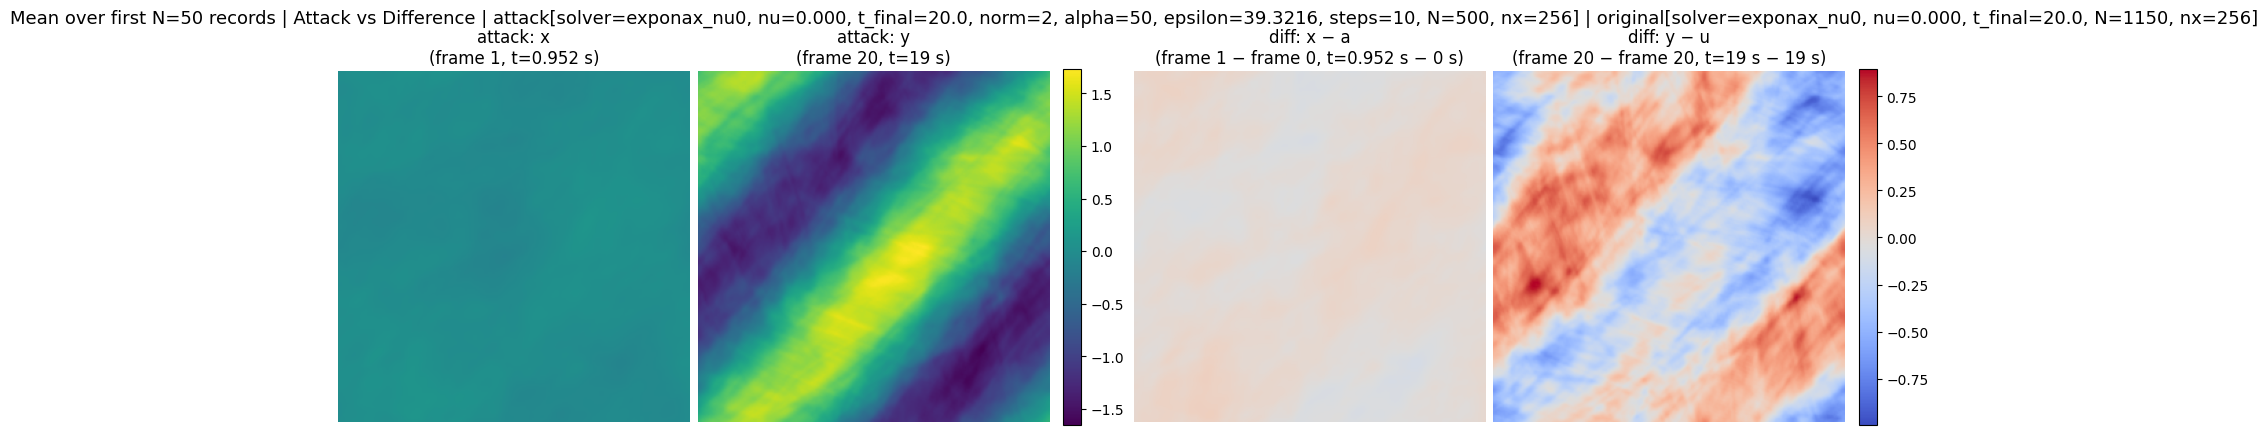

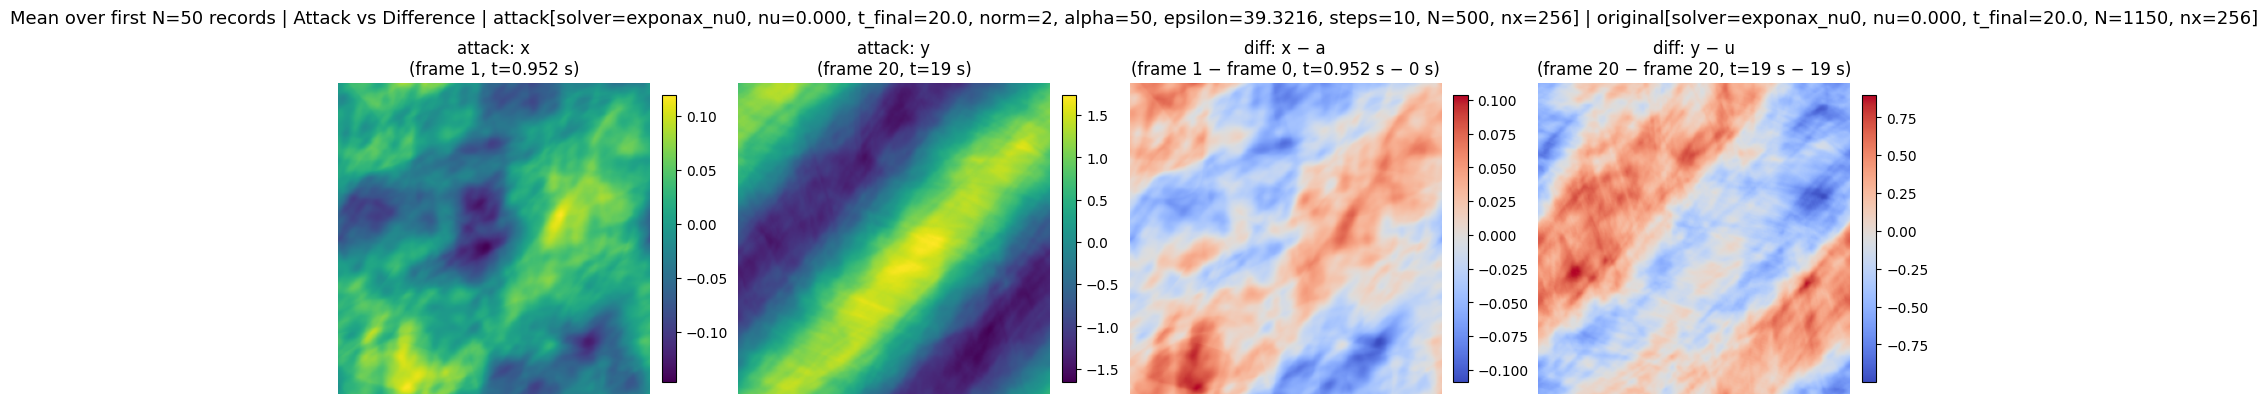

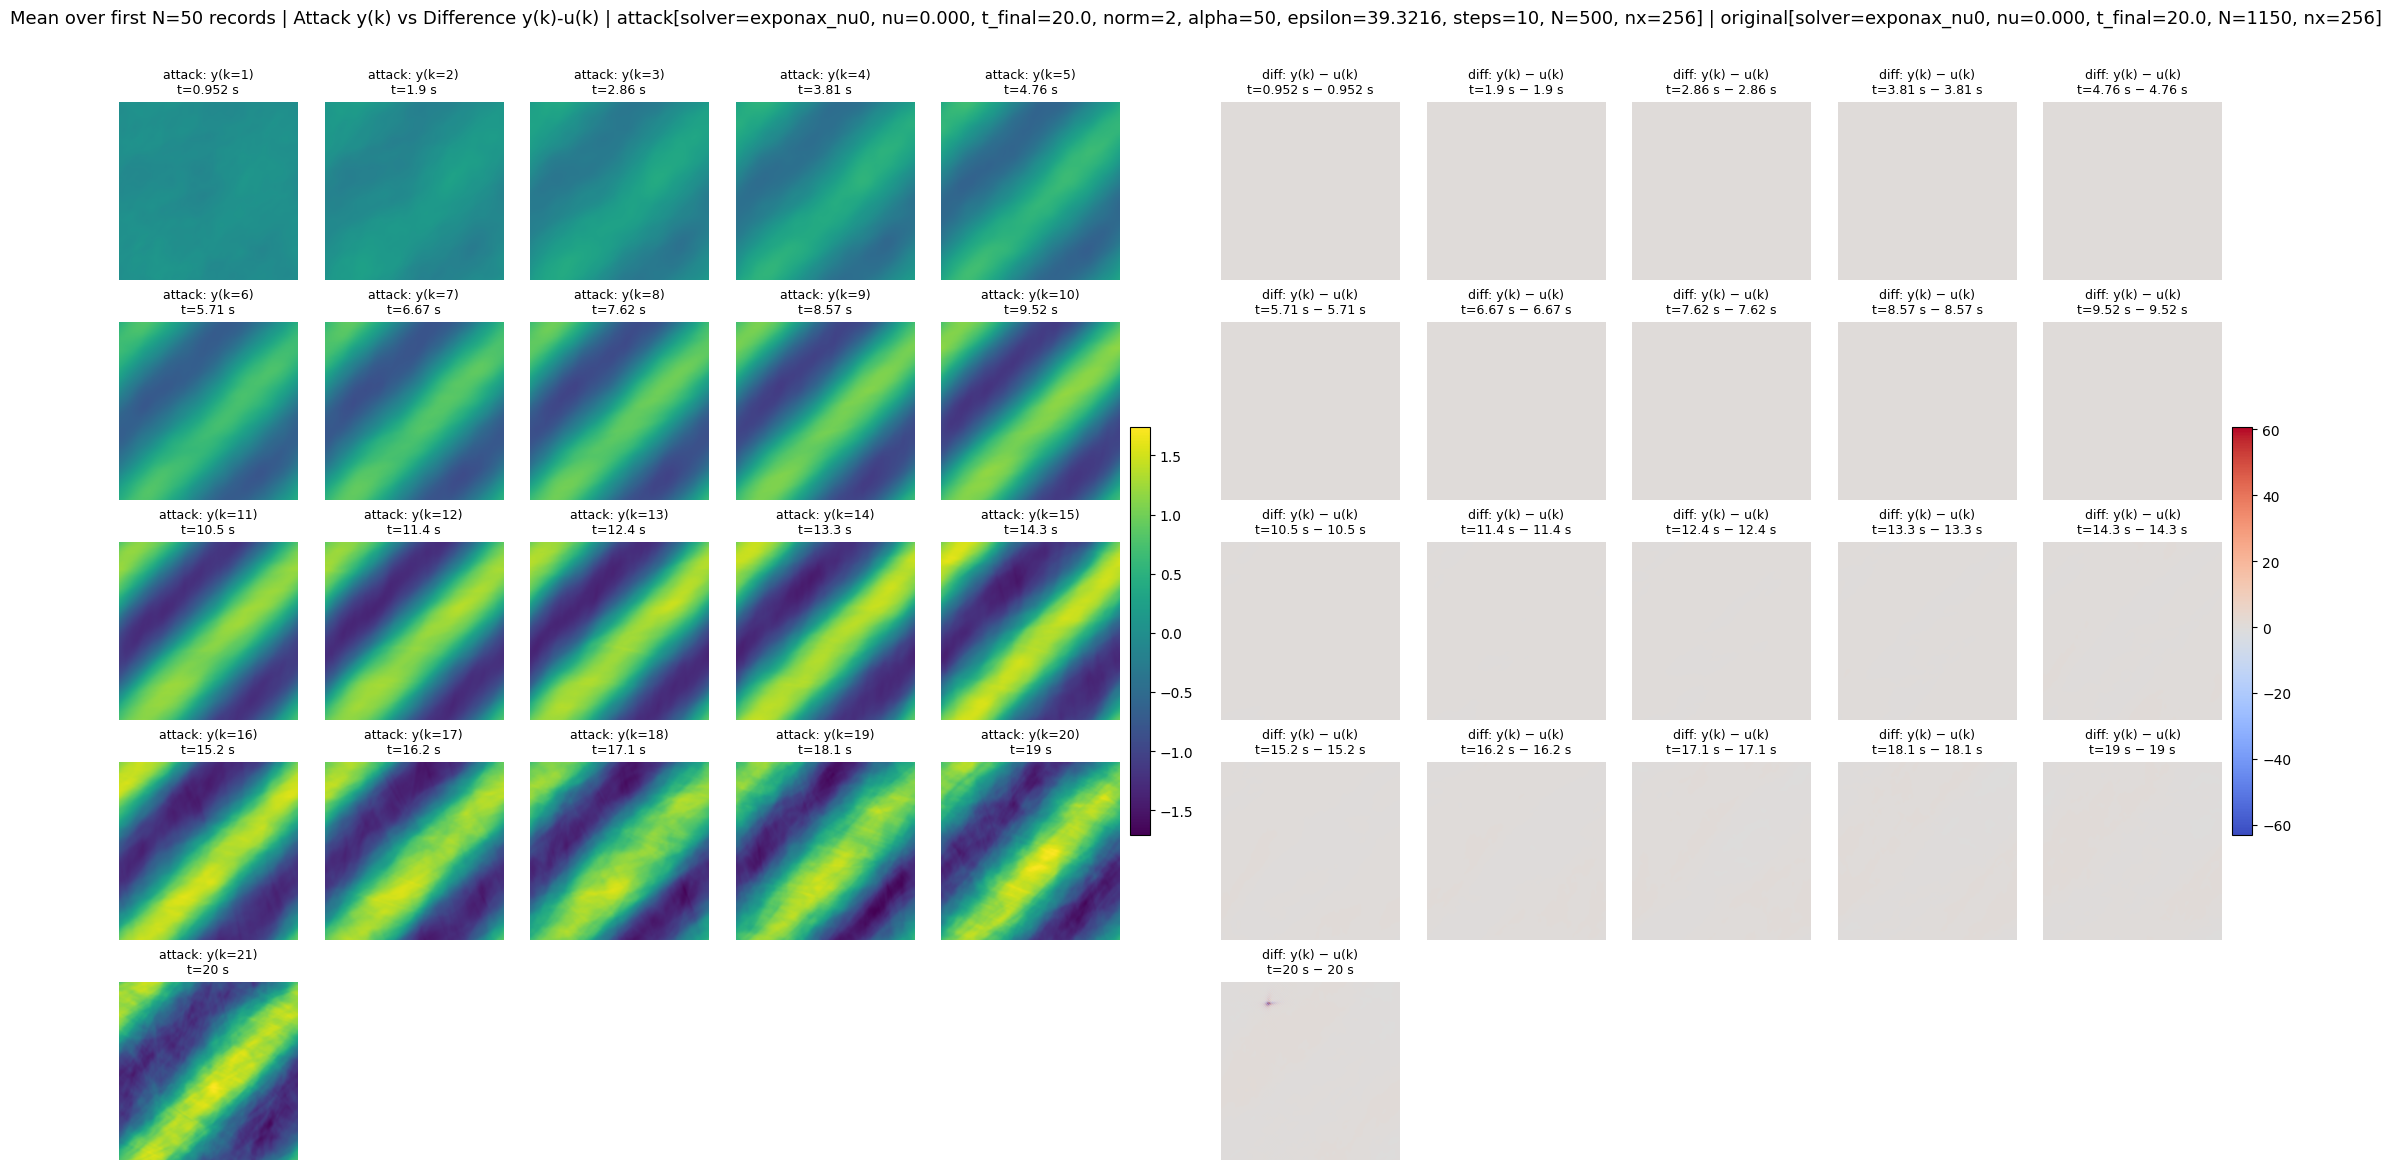

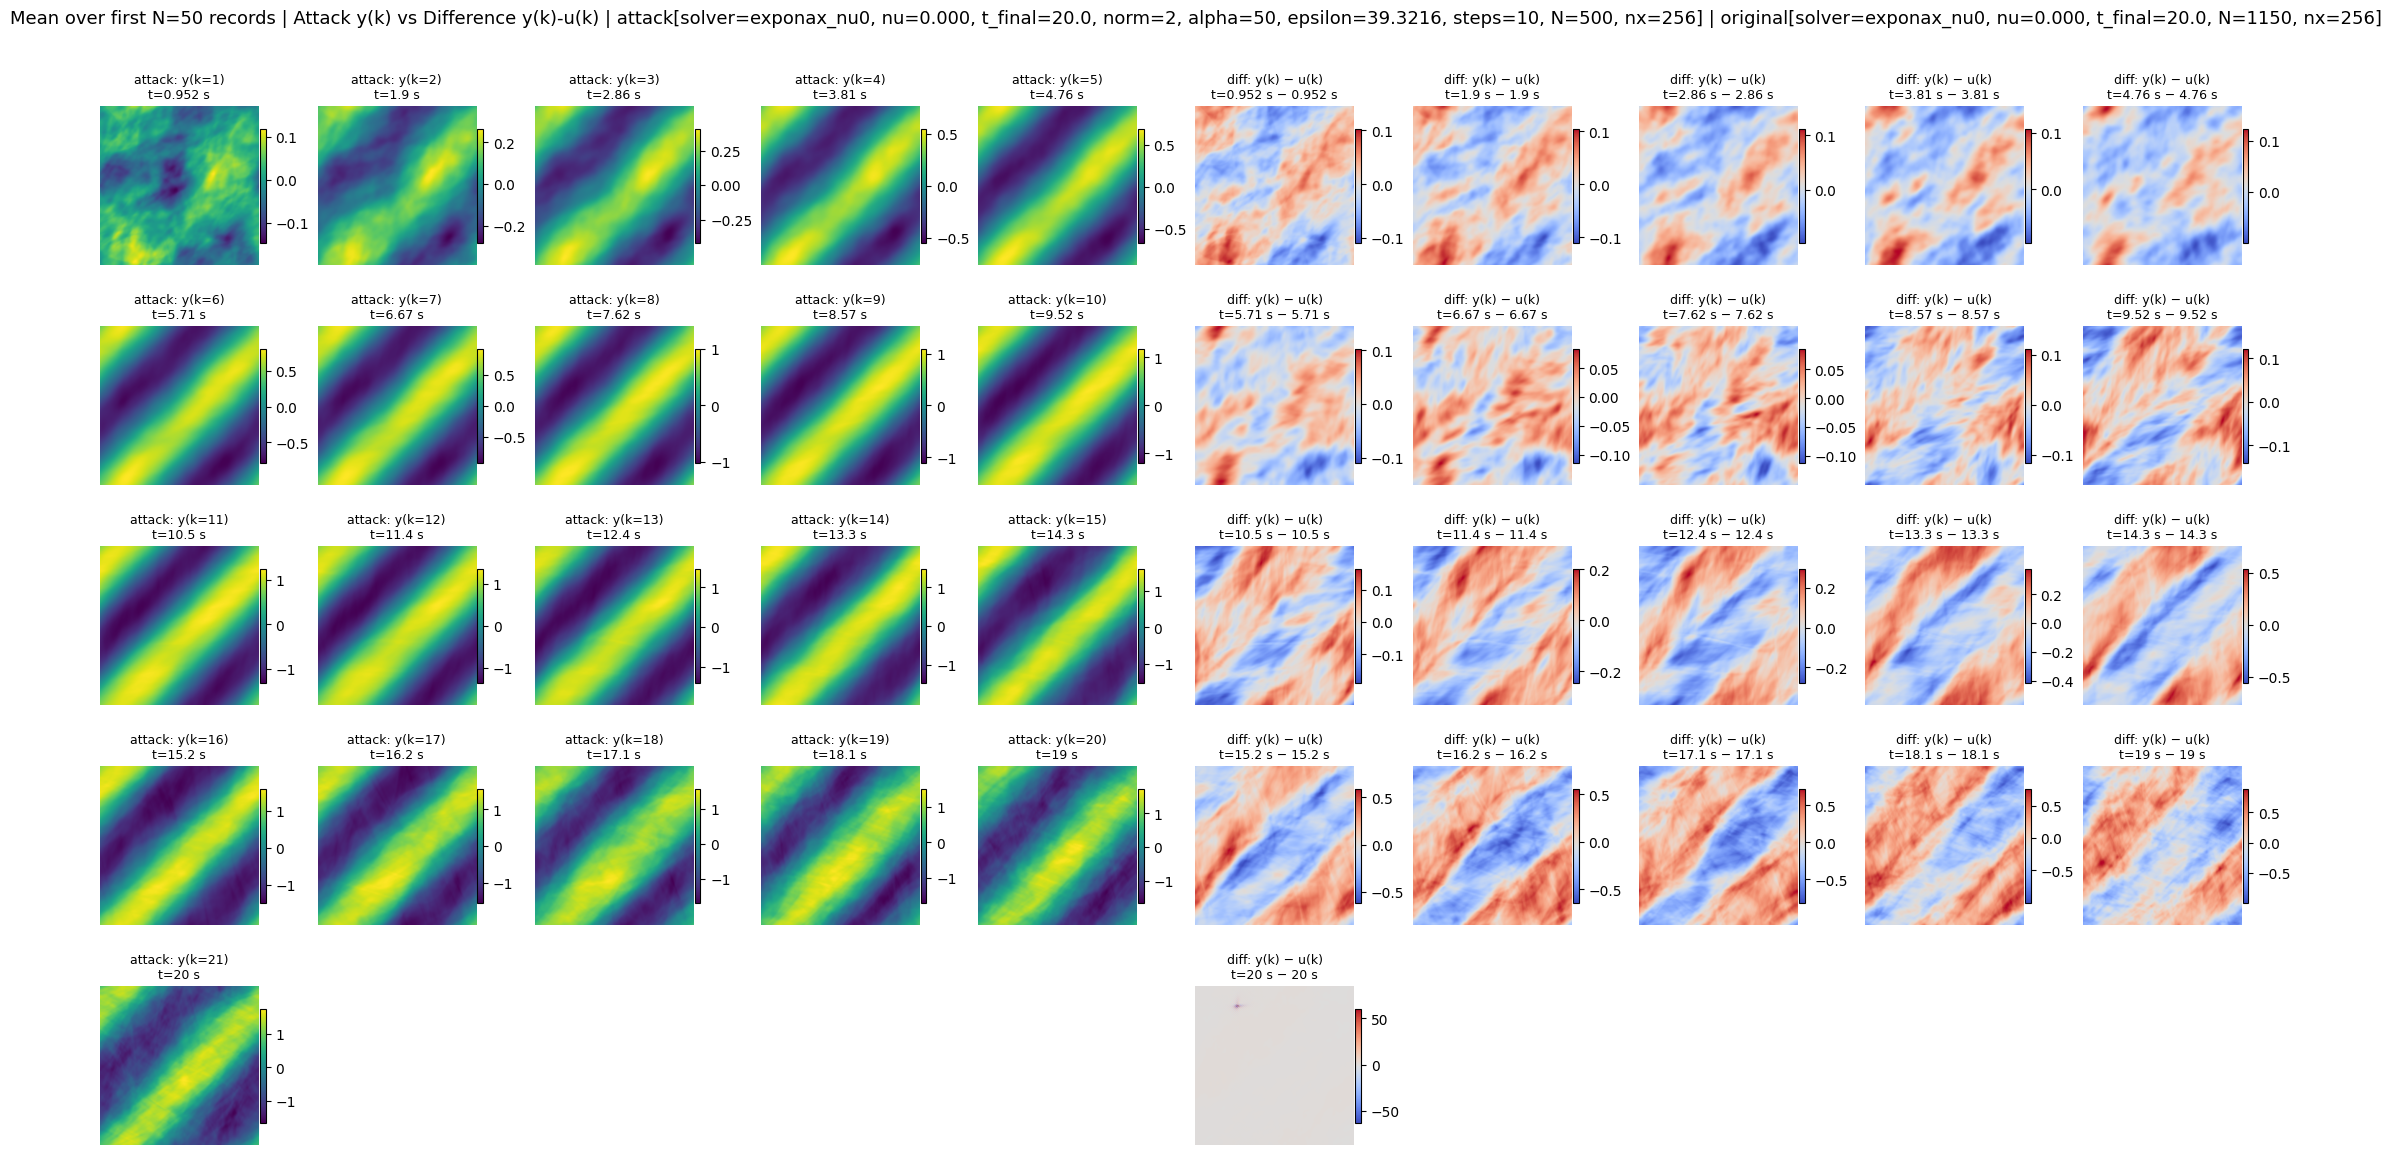

(<Figure size 2200x1100 with 92 Axes>,
 array([[<Axes: title={'center': 'attack: y(k=1)\nt=0.952 s'}>,
         <Axes: title={'center': 'attack: y(k=2)\nt=1.9 s'}>,
         <Axes: title={'center': 'attack: y(k=3)\nt=2.86 s'}>,
         <Axes: title={'center': 'attack: y(k=4)\nt=3.81 s'}>,
         <Axes: title={'center': 'attack: y(k=5)\nt=4.76 s'}>,
         <Axes: title={'center': 'diff: y(k) − u(k)\nt=0.952 s − 0.952 s'}>,
         <Axes: title={'center': 'diff: y(k) − u(k)\nt=1.9 s − 1.9 s'}>,
         <Axes: title={'center': 'diff: y(k) − u(k)\nt=2.86 s − 2.86 s'}>,
         <Axes: title={'center': 'diff: y(k) − u(k)\nt=3.81 s − 3.81 s'}>,
         <Axes: title={'center': 'diff: y(k) − u(k)\nt=4.76 s − 4.76 s'}>],
        [<Axes: title={'center': 'attack: y(k=6)\nt=5.71 s'}>,
         <Axes: title={'center': 'attack: y(k=7)\nt=6.67 s'}>,
         <Axes: title={'center': 'attack: y(k=8)\nt=7.62 s'}>,
         <Axes: title={'center': 'attack: y(k=9)\nt=8.57 s'}>,
         <Axes: ti

In [16]:
pt_attack = "dim2d_nx256_N500_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha50_epsilon39.3216_steps10.pt"
# pt_attack = "dim2d_nx256_N500_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha10_epsilon39.3216_steps10.pt"

pt_orig   = "../../../exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt" # a=frame0, u=frames 1..T

# 单图（指定帧 k；对前 N 条取均值）
plot_xy_compare_attack_original_avg(pt_attack, pt_orig, N=50, t_idx=19, cbar_mode="shared")
plot_xy_compare_attack_original_avg(pt_attack, pt_orig, N=50, t_idx=19, cbar_mode="separate")
# 多帧翻倍（5×10；对前 N 条取均值）
plot_frames_y_and_diff_side_by_side_avg(pt_attack, pt_orig, N=50, grid=(5,5), cbar_mode="shared")
plot_frames_y_and_diff_side_by_side_avg(pt_attack, pt_orig, N=50, grid=(5,5), cbar_mode="separate")

In [13]:
data = torch.load("dim2d_nx256_N500_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha10_epsilon39.3216_steps10.pt", map_location="cpu", weights_only=False)

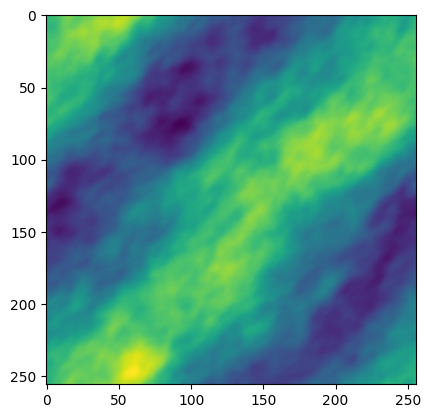

In [14]:
plt.imshow(data["y"][...,0].mean(axis=0))

In [1]:
import torch, math
#Resolution
s = 256

#Number of solutions to generate
N = 2

#Forcing function: 0.1*(sin(2pi(x+y)) + cos(2pi(x+y)))
t = torch.linspace(0, 1, s+1)
t = t[0:-1]

X,Y = torch.meshgrid(t, t, indexing='ij')
f = 0.1*(torch.sin(2*math.pi*(X + Y)) + torch.cos(2*math.pi*(X + Y)))

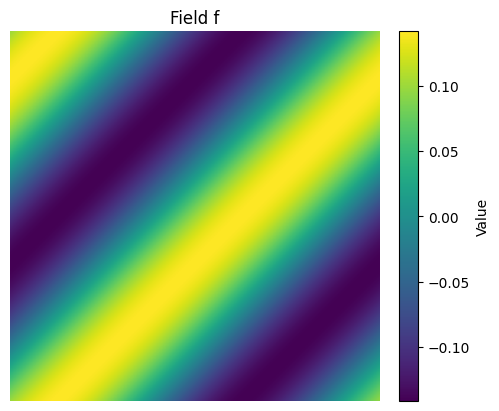

In [8]:
import matplotlib.pyplot as plt

im = plt.imshow(f, cmap='viridis')  # 可改 colormap
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label('Value')             # 可选：色条标签
plt.title('Field f')
plt.axis('off')                     # 想保留坐标就删掉
plt.show()

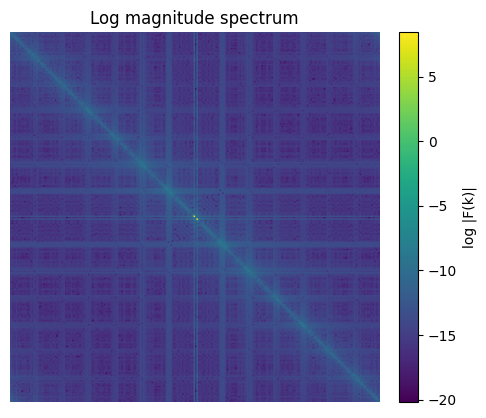

In [5]:
import numpy as np
import matplotlib.pyplot as plt

eps = 1e-12  # 避免 log(0)
F = np.fft.fftshift(np.fft.fft2(f))
spec = np.log(np.abs(F) + eps)

fig, ax = plt.subplots()
im = ax.imshow(spec, cmap='viridis')   # 也可换成你喜欢的 cmap
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('log |F(k)|')

ax.set_title('Log magnitude spectrum')
ax.set_axis_off()  # 想看坐标就改成：ax.set_aspect('equal')
plt.show()


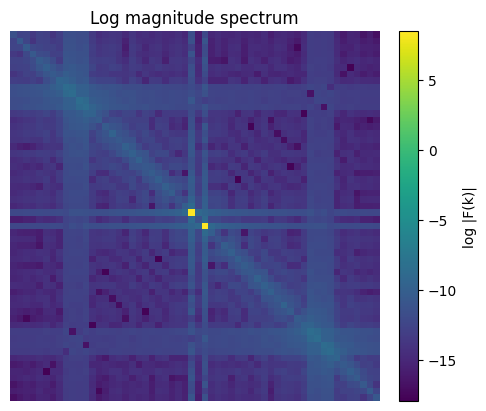

In [7]:
import numpy as np
import matplotlib.pyplot as plt

eps = 1e-12  # 避免 log(0)
F = np.fft.fftshift(np.fft.fft2(f))
spec = np.log(np.abs(F) + eps)

fig, ax = plt.subplots()
im = ax.imshow(spec[100:156,100:156], cmap='viridis')   # 也可换成你喜欢的 cmap
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('log |F(k)|')

ax.set_title('Log magnitude spectrum')
ax.set_axis_off()  # 想看坐标就改成：ax.set_aspect('equal')
plt.show()